# Comment Category Prediction

The goal here is to predict which category a user comment belongs to, based on the comment text and various metadata signals like upvotes, emoticons, and demographic identifiers.

My approach:
1. Thorough EDA to understand what the data actually looks like
2. Feature engineering on the text and metadata
3. TF-IDF vectorization (word-level + char-level)
4. Train 3 models and compare them
5. Ensemble the top two models using the best-found weights

In [1]:
# all imports upfront so I don't have to hunt for missing ones later
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from scipy.sparse import hstack
import lightgbm as lgb

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

# just confirming the input files are where I expect them
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


## 1. Load Data

In [2]:
train  = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
test   = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')
sample = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/Sample.csv')

print(f'Train: {train.shape}  |  Test: {test.shape}')
train.head()

Train: (198000, 15)  |  Test: (102000, 14)


,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


## 2. Exploratory Data Analysis

Before jumping into modelling, I want to understand what the data actually contains — what the features mean, how balanced the classes are, where the missing values are, and what the text looks like.

In [3]:
# basic overview: dtypes, non-null counts, memory
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


In [4]:
# numeric summary — useful for spotting weird min/max values
train.describe()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,label
count,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000
mean,68.447429,0.279768,0.048338,0.121071,2.607975,0.666394,1.906152,7.956212,0.793965
std,27.948390,1.023234,0.258477,0.481013,5.054763,2.044335,25.635752,14.839464,0.979808
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000,2.000000
max,129.000000,47.000000,11.000000,17.000000,201.000000,107.000000,1860.000000,1833.000000,3.000000


### 2.1 Target Distribution

This is a multiclass problem with 4 classes (0, 1, 2, 3). Before doing anything else I need to check if the classes are balanced — if they aren't, a naive model would just predict the majority class all the time.

Label counts and percentages:
  Class 0: 114,173  (57.66%)
  Class 1:  15,918  (8.04%)
  Class 2:  62,440  (31.54%)
  Class 3:   5,469  (2.76%)


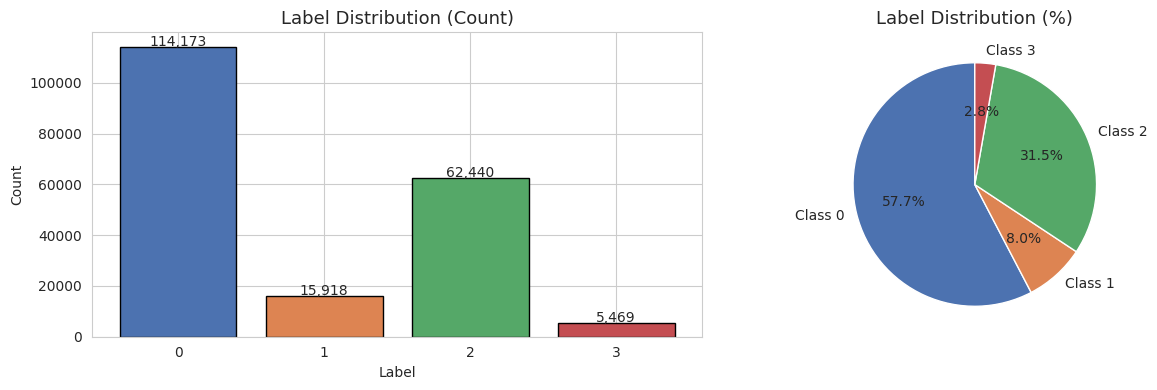


Insight: The dataset is heavily imbalanced. Class 0 makes up ~57% of the data,
while Class 3 is only ~2.8%. This means a dummy model that always predicts 0
would score ~57%, so we need to do much better than that.


In [5]:
label_counts = train['label'].value_counts().sort_index()
label_pct    = (label_counts / len(train) * 100).round(2)

print('Label counts and percentages:')
for lbl, cnt, pct in zip(label_counts.index, label_counts.values, label_pct.values):
    print(f'  Class {lbl}: {cnt:>7,}  ({pct:.2f}%)')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# count bar
axes[0].bar(label_counts.index.astype(str), label_counts.values, color=['#4C72B0','#DD8452','#55A868','#C44E52'], edgecolor='black')
axes[0].set_title('Label Distribution (Count)', fontsize=13)
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=10)

# pie chart
axes[1].pie(label_counts.values, labels=[f'Class {l}' for l in label_counts.index],
            autopct='%1.1f%%', startangle=90,
            colors=['#4C72B0','#DD8452','#55A868','#C44E52'])
axes[1].set_title('Label Distribution (%)', fontsize=13)

plt.tight_layout()
plt.show()

print('\nInsight: The dataset is heavily imbalanced. Class 0 makes up ~57% of the data,')
print('while Class 3 is only ~2.8%. This means a dummy model that always predicts 0')
print('would score ~57%, so we need to do much better than that.')

### 2.2 Missing Values

Columns with missing values:
          Missing Count  Missing %
race             145423      73.45
religion         145423      73.45
gender           145423      73.45
comment               1       0.00


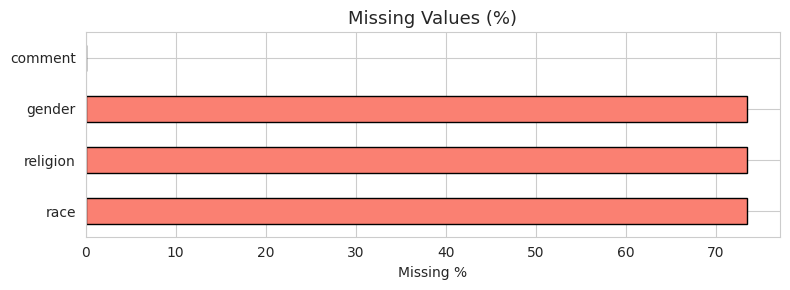


Insight: race, religion, gender are missing in ~73% of rows — these columns
exist only when the comment references those topics. So NaN here means
'not applicable', not truly missing. We will fill them with empty string.
The comment column has just 1 missing value — easy to fill.


In [6]:
missing = train.isnull().sum()
missing_pct = (missing / len(train) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

print('Columns with missing values:')
print(missing_df.to_string())

# visualize
if len(missing_df) > 0:
    plt.figure(figsize=(8, 3))
    missing_df['Missing %'].plot(kind='barh', color='salmon', edgecolor='black')
    plt.title('Missing Values (%)', fontsize=13)
    plt.xlabel('Missing %')
    plt.tight_layout()
    plt.show()

print('\nInsight: race, religion, gender are missing in ~73% of rows — these columns')
print('exist only when the comment references those topics. So NaN here means')
print("'not applicable', not truly missing. We will fill them with empty string.")
print('The comment column has just 1 missing value — easy to fill.')

### 2.3 Comment Length Analysis

The length of a comment often tells us something about its tone and category. Very short comments might be dismissive or reactive; longer ones tend to be more analytical.

Comment length stats (characters):
count    198000.0
mean        302.9
std         266.4
min           0.0
25%         102.0
50%         211.0
75%         419.0
max        1892.0
Name: char_len, dtype: float64

Comment length stats (words):
count    198000.0
mean         52.4
std          45.8
min           0.0
25%          18.0
50%          37.0
75%          73.0
max         315.0
Name: word_len, dtype: float64


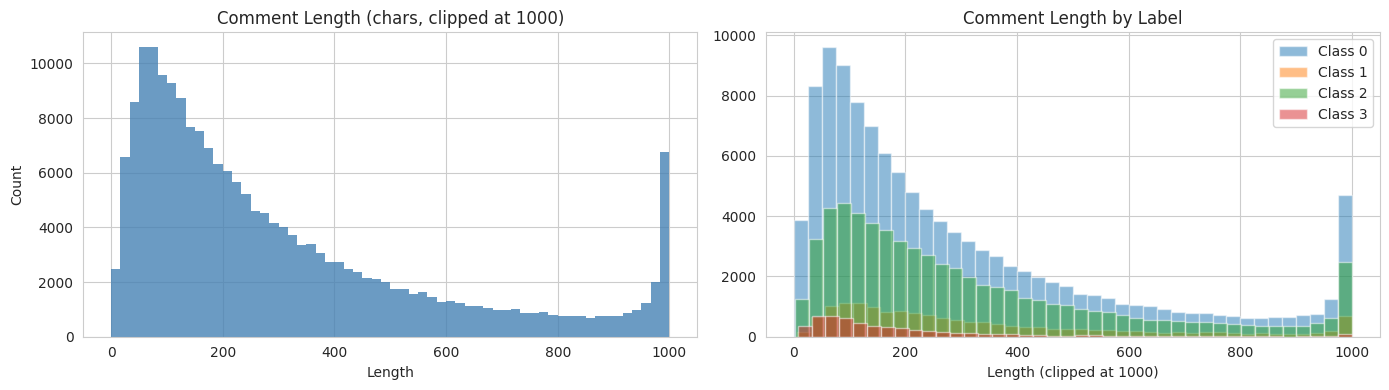

Median character length per class:
label
0    199.0
1    246.0
2    232.0
3    128.0
Name: char_len, dtype: float64

Insight: Different classes have noticeably different comment length distributions,
which means comment length will be a useful feature for the model.


In [7]:
# compute length on a temp copy so we don't pollute the df yet
tmp = train.copy()
tmp['comment'] = tmp['comment'].fillna('')
tmp['char_len'] = tmp['comment'].apply(len)
tmp['word_len'] = tmp['comment'].str.split().str.len().fillna(0).astype(int)

print('Comment length stats (characters):')
print(tmp['char_len'].describe().round(1))
print('\nComment length stats (words):')
print(tmp['word_len'].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# overall char length distribution
axes[0].hist(tmp['char_len'].clip(upper=1000), bins=60, color='steelblue', edgecolor='none', alpha=0.8)
axes[0].set_title('Comment Length (chars, clipped at 1000)', fontsize=12)
axes[0].set_xlabel('Length')
axes[0].set_ylabel('Count')

# char length by label — do certain classes have longer comments?
label_names = {0: 'Class 0', 1: 'Class 1', 2: 'Class 2', 3: 'Class 3'}
for label in sorted(tmp['label'].unique()):
    subset = tmp[tmp['label'] == label]['char_len'].clip(upper=1000)
    axes[1].hist(subset, bins=40, alpha=0.5, label=label_names[label])
axes[1].set_title('Comment Length by Label', fontsize=12)
axes[1].set_xlabel('Length (clipped at 1000)')
axes[1].legend()

plt.tight_layout()
plt.show()

# median length per class
print('Median character length per class:')
print(tmp.groupby('label')['char_len'].median())
print('\nInsight: Different classes have noticeably different comment length distributions,')
print('which means comment length will be a useful feature for the model.')

### 2.4 Engagement Signals: Upvotes & Downvotes

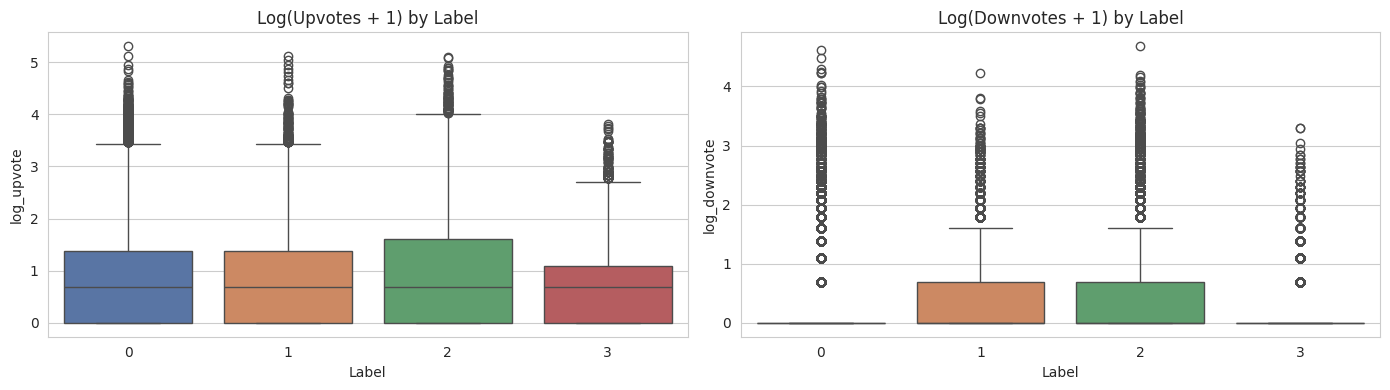

Upvote stats per class:
          count  mean   std  min  25%  50%  75%    max
label                                                 
0      114173.0  2.40  4.60  0.0  0.0  1.0  3.0  201.0
1       15918.0  2.85  6.05  0.0  0.0  1.0  3.0  166.0
2       62440.0  2.97  5.61  0.0  0.0  1.0  4.0  163.0
3        5469.0  2.04  3.77  0.0  0.0  1.0  2.0   44.0

Insight: Some classes receive more upvotes or downvotes on average,
so engagement metrics carry predictive signal.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# log scale because upvote distributions are heavily right-skewed
tmp['log_upvote']   = np.log1p(tmp['upvote'])
tmp['log_downvote'] = np.log1p(tmp['downvote'])

sns.boxplot(x='label', y='log_upvote', data=tmp, ax=axes[0],
            palette=['#4C72B0','#DD8452','#55A868','#C44E52'])
axes[0].set_title('Log(Upvotes + 1) by Label', fontsize=12)
axes[0].set_xlabel('Label')

sns.boxplot(x='label', y='log_downvote', data=tmp, ax=axes[1],
            palette=['#4C72B0','#DD8452','#55A868','#C44E52'])
axes[1].set_title('Log(Downvotes + 1) by Label', fontsize=12)
axes[1].set_xlabel('Label')

plt.tight_layout()
plt.show()

print('Upvote stats per class:')
print(tmp.groupby('label')['upvote'].describe().round(2))
print('\nInsight: Some classes receive more upvotes or downvotes on average,')
print('so engagement metrics carry predictive signal.')

### 2.5 Emoticons and Flag Signals

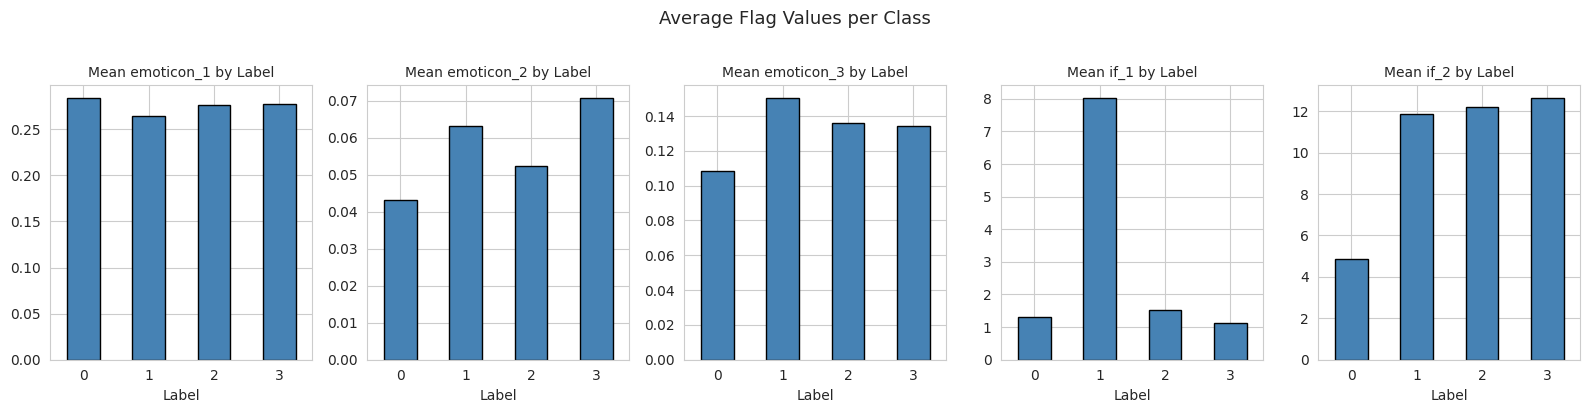

Insight: emoticon_2 and emoticon_3 in particular show different average values
across classes, confirming they carry label signal beyond just noise.


In [9]:
# emoticon_1/2/3 and if_1/if_2 are binary/numeric flags
# worth checking if they differ across classes
flag_cols = ['emoticon_1', 'emoticon_2', 'emoticon_3', 'if_1', 'if_2']

fig, axes = plt.subplots(1, len(flag_cols), figsize=(16, 4))
for i, col in enumerate(flag_cols):
    tmp.groupby('label')[col].mean().plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].set_title(f'Mean {col} by Label', fontsize=10)
    axes[i].set_xlabel('Label')
    axes[i].tick_params(axis='x', rotation=0)

plt.suptitle('Average Flag Values per Class', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('Insight: emoticon_2 and emoticon_3 in particular show different average values')
print('across classes, confirming they carry label signal beyond just noise.')

### 2.6 Demographic Columns

In [10]:
# only about 27% of rows have values here, so let's look at what they contain
for col in ['race', 'religion', 'gender']:
    non_null = train[col].dropna()
    print(f'--- {col} ({len(non_null)} non-null rows) ---')
    print(non_null.value_counts().head(10))
    print()

print('Insight: These columns contain string category labels like "black", "none", "christian" etc.')
print('When a comment mentions a demographic group, this field is filled in.')
print('We will convert NaN -> empty string and treat them as plain numeric via get_dummies.')

--- race (52577 non-null rows) ---
race
none      39682
white      5486
black      3869
other      1654
asian      1263
latino      623
Name: count, dtype: int64

--- religion (52577 non-null rows) ---
religion
none         38249
christian     7191
muslim        4930
jewish        1244
other          547
atheist        219
buddhist       100
hindu           97
Name: count, dtype: int64

--- gender (52577 non-null rows) ---
gender
none           36161
female          8037
male            7549
transgender      622
other            208
Name: count, dtype: int64

Insight: These columns contain string category labels like "black", "none", "christian" etc.
When a comment mentions a demographic group, this field is filled in.
We will convert NaN -> empty string and treat them as plain numeric via get_dummies.


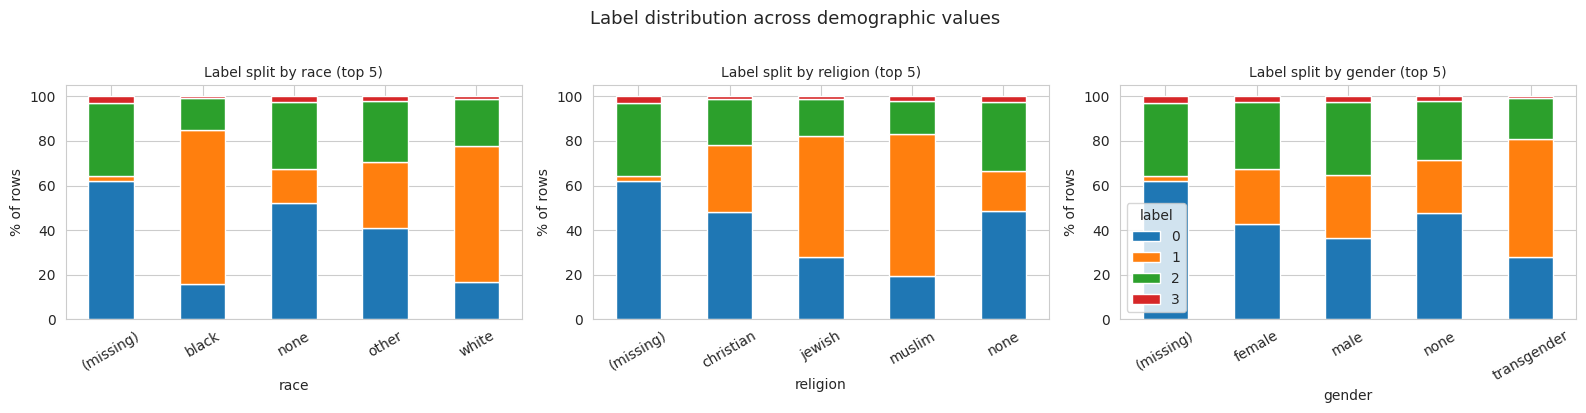

In [11]:
# do certain demographic tags correlate with label?
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, col in enumerate(['race', 'religion', 'gender']):
    filled = train[col].fillna('(missing)')
    top_vals = filled.value_counts().head(5).index
    subset = train[filled.isin(top_vals)].copy()
    subset[col] = filled[filled.isin(top_vals)]
    ct = pd.crosstab(subset[col], subset['label'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[i], legend=(i == 2))
    axes[i].set_title(f'Label split by {col} (top 5)', fontsize=10)
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].set_ylabel('% of rows')

plt.suptitle('Label distribution across demographic values', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 2.7 Time Patterns

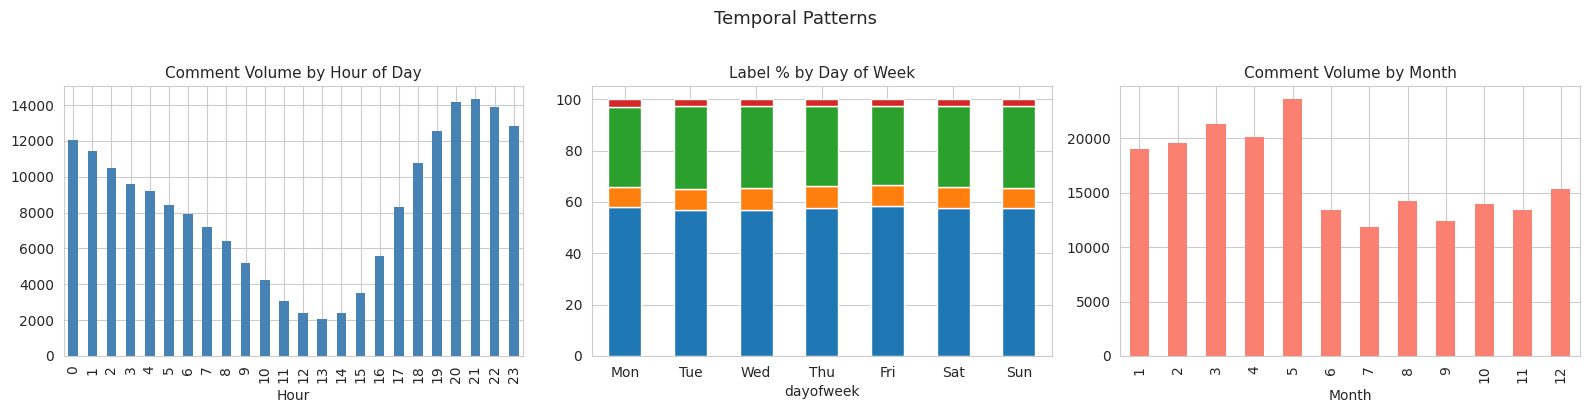

Insight: There is some variation in comment volume across hours and days,
so hour/dayofweek/month might add marginal predictive value.


In [12]:
tmp['created_date'] = pd.to_datetime(train['created_date'], errors='coerce')
tmp['hour']      = tmp['created_date'].dt.hour
tmp['dayofweek'] = tmp['created_date'].dt.dayofweek  # 0=Monday, 6=Sunday
tmp['month']     = tmp['created_date'].dt.month

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# comments by hour
tmp.groupby('hour')['label'].count().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='none')
axes[0].set_title('Comment Volume by Hour of Day', fontsize=11)
axes[0].set_xlabel('Hour')

# label distribution by day of week
dow_label = tmp.groupby(['dayofweek', 'label']).size().unstack(fill_value=0)
dow_label = dow_label.div(dow_label.sum(axis=1), axis=0) * 100
dow_label.plot(kind='bar', stacked=True, ax=axes[1], legend=False)
axes[1].set_title('Label % by Day of Week', fontsize=11)
axes[1].set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], rotation=0)

# volume by month
tmp.groupby('month')['label'].count().plot(kind='bar', ax=axes[2], color='salmon', edgecolor='none')
axes[2].set_title('Comment Volume by Month', fontsize=11)
axes[2].set_xlabel('Month')

plt.suptitle('Temporal Patterns', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('Insight: There is some variation in comment volume across hours and days,')
print('so hour/dayofweek/month might add marginal predictive value.')

del tmp  # done with temp df

### 2.8 Correlation Heatmap (Numeric Features)

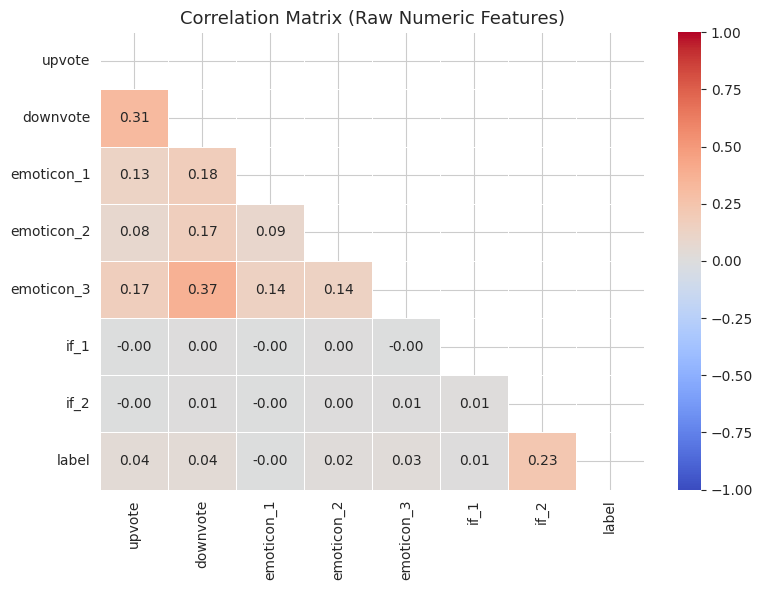

Insight: Most numeric features have low correlation with the label individually.
This is expected — the main signal is in the text. But combined with TF-IDF,
even weak individual features can improve the model at the margin.


In [13]:
# quick correlation check on the raw numeric columns before feature engineering
num_cols_eda = ['upvote', 'downvote', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'if_1', 'if_2', 'label']
corr = train[num_cols_eda].corr()

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', mask=mask,
            vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix (Raw Numeric Features)', fontsize=13)
plt.tight_layout()
plt.show()

print('Insight: Most numeric features have low correlation with the label individually.')
print('This is expected — the main signal is in the text. But combined with TF-IDF,')
print('even weak individual features can improve the model at the margin.')

## 3. Preprocessing & Feature Engineering

Based on what I saw in EDA, here's the plan:
- Fill missing text/demographic columns with empty string
- One-hot encode race/religion/gender (they are categorical strings)
- Build text-derived numeric features (length, caps ratio, punctuation, etc.)
- Add time-based features from the date column
- Log-transform upvotes (right-skewed)
- Apply TF-IDF on the comment text (word-level and char-level)

In [14]:
# fill missing values
# for comment: 1 row is null, just replace with empty string
# for race/religion/gender: NaN means 'not mentioned', treat as empty string
for df in [train, test]:
    df['comment']  = df['comment'].fillna('')
    df['race']     = df['race'].fillna('').astype(str)
    df['religion'] = df['religion'].fillna('').astype(str)
    df['gender']   = df['gender'].fillna('').astype(str)

# one-hot encode the demographic columns
train = pd.get_dummies(train, columns=['race', 'religion', 'gender'])
test  = pd.get_dummies(test,  columns=['race', 'religion', 'gender'])

# align so test has all columns train has (fill any new ones with 0)
train, test = train.align(test, join='left', axis=1, fill_value=0)
print(f'After encoding — train: {train.shape}  test: {test.shape}')

After encoding — train: (198000, 34)  test: (102000, 34)


In [15]:
# text-derived numeric features
# the idea is to give the model stylistic signals that TF-IDF might miss
for df in [train, test]:
    c = df['comment']

    # length
    df['comment_length'] = c.apply(len)
    df['word_count']     = c.str.split().str.len().fillna(0).astype(int)
    df['avg_word_len']   = df['comment_length'] / (df['word_count'] + 1)

    # vocabulary diversity — repetitive text scores low here
    df['unique_word_count'] = c.apply(lambda x: len(set(x.lower().split())))
    df['unique_word_ratio'] = df['unique_word_count'] / (df['word_count'] + 1)

    # punctuation signals
    df['excl_count'] = c.str.count('!')                # excitement / aggression
    df['ques_count'] = c.str.count(r'\?')              # questioning tone

    # caps — ALL CAPS writing is often emotional or hostile
    df['capital_count'] = c.apply(lambda x: sum(1 for ch in x if ch.isupper()))
    df['capital_ratio'] = df['capital_count'] / (df['comment_length'] + 1)

print('Text features added.')

Text features added.


In [16]:
# time-based features
train['created_date'] = pd.to_datetime(train['created_date'], errors='coerce')
test['created_date']  = pd.to_datetime(test['created_date'],  errors='coerce')

for df in [train, test]:
    df['hour']      = df['created_date'].dt.hour.fillna(0).astype(int)
    df['day']       = df['created_date'].dt.day.fillna(0).astype(int)
    df['dayofweek'] = df['created_date'].dt.dayofweek.fillna(0).astype(int)

# log-transform upvotes and downvotes to reduce skew
for df in [train, test]:
    df['log_upvote']   = np.log1p(df['upvote'])
    df['log_downvote'] = np.log1p(df['downvote'])

print('Time + log-engagement features added.')

Time + log-engagement features added.


## 4. TF-IDF Vectorization

Two vectorizers:
- **Word-level (unigrams + bigrams):** captures standard vocabulary patterns
- **Char-level (3–5 grams):** captures subword patterns, handles misspellings, slang, prefixes

In [17]:
# word-level TF-IDF
# sublinear_tf=True dampens the effect of very frequent terms
# min_df=2 removes terms that only appear once (noise)
# max_df=0.95 removes terms that appear in almost every document (stop-word like)
print('Fitting Word TF-IDF...')
word_tfidf = TfidfVectorizer(
    max_features=25000,
    ngram_range=(1, 2),
    stop_words='english',
    sublinear_tf=True,
    min_df=2,
    max_df=0.95
)
X_word      = word_tfidf.fit_transform(train['comment'])
X_test_word = word_tfidf.transform(test['comment'])
print(f'  Word features: {X_word.shape[1]}')

# char-level TF-IDF
# char_wb means it respects word boundaries (pads with spaces)
print('Fitting Char TF-IDF...')
char_tfidf = TfidfVectorizer(
    max_features=25000,
    analyzer='char_wb',
    ngram_range=(3, 5),
    sublinear_tf=True,
    min_df=2,
    max_df=0.95
)
X_char      = char_tfidf.fit_transform(train['comment'])
X_test_char = char_tfidf.transform(test['comment'])
print(f'  Char features: {X_char.shape[1]}')

Fitting Word TF-IDF...
  Word features: 25000
Fitting Char TF-IDF...
  Char features: 25000


In [18]:
# numeric feature columns
# exclude raw text, label, date and the original upvote/downvote (replaced by log version)
skip_cols = ['comment', 'label', 'created_date', 'upvote', 'downvote']
num_cols  = [c for c in train.columns if c not in skip_cols]

X_num      = train[num_cols].apply(pd.to_numeric, errors='coerce').fillna(0).astype('float32')
X_test_num = test[num_cols].apply(pd.to_numeric,  errors='coerce').fillna(0).astype('float32')

# stack everything into one big sparse matrix
from scipy.sparse import csr_matrix
X      = hstack([X_word, X_char, csr_matrix(X_num.values)])
X_test = hstack([X_test_word, X_test_char, csr_matrix(X_test_num.values)])

print(f'Final feature matrix — train: {X.shape}  test: {X_test.shape}')

Final feature matrix — train: (198000, 50043)  test: (102000, 50043)


In [19]:
# encode target labels (0/1/2/3 are already numeric so this is mainly for inverse_transform later)
le = LabelEncoder()
y  = le.fit_transform(train['label'])
print('Classes:', le.classes_)

# stratified split — ensures both train and val have the same class proportions
# this matters because the dataset is imbalanced
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]}  Val: {X_val.shape[0]}')

Classes: [0 1 2 3]
Train: 158400  Val: 39600


## 5. Model Training & Comparison

I'm training three models:
1. **Naive Bayes** — fast probabilistic baseline, works well on sparse text features
2. **Logistic Regression** — linear model, good benchmark for TF-IDF problems
3. **LightGBM** — gradient boosted trees, typically best on structured + text mixed problems

After comparing all three, I'll ensemble the two strongest ones.

In [20]:
# ---- Model 1: Naive Bayes ----
# alpha is the Laplace smoothing parameter — small value works better here
print('Training Naive Bayes...')
nb = MultinomialNB(alpha=0.1)
nb.fit(X_train, y_train)
nb_pred = nb.predict(X_val)
nb_acc  = accuracy_score(y_val, nb_pred)
print(f'  NB Accuracy: {nb_acc:.4f}')

Training Naive Bayes...
  NB Accuracy: 0.4534


In [21]:
# ---- Model 2: Logistic Regression ----
# lbfgs solver handles multiclass well; C=1.0 is standard regularization strength
print('Training Logistic Regression...')
lr = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs', random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_val)
lr_acc  = accuracy_score(y_val, lr_pred)
print(f'  LR Accuracy: {lr_acc:.4f}')

Training Logistic Regression...
  LR Accuracy: 0.8760


In [22]:
# ---- Model 3: LightGBM ----
# is_unbalance=True adjusts class weights internally to handle the imbalance
# early_stopping stops training if val accuracy doesn't improve for 50 rounds
print('Training LightGBM...')
lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=64,
    max_depth=8,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
    is_unbalance=True
)
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False)]
)
lgb_pred = lgb_model.predict(X_val)
lgb_acc  = accuracy_score(y_val, lgb_pred)
print(f'  LGB Accuracy: {lgb_acc:.4f}')
print(f'  Best iteration: {lgb_model.best_iteration_}')

Training LightGBM...
  LGB Accuracy: 0.9158
  Best iteration: 500


### 5.1 Model Comparison

=== Model Comparison ===
              Model  Val Accuracy
           LightGBM      0.915758
Logistic Regression      0.875985
        Naive Bayes      0.453409


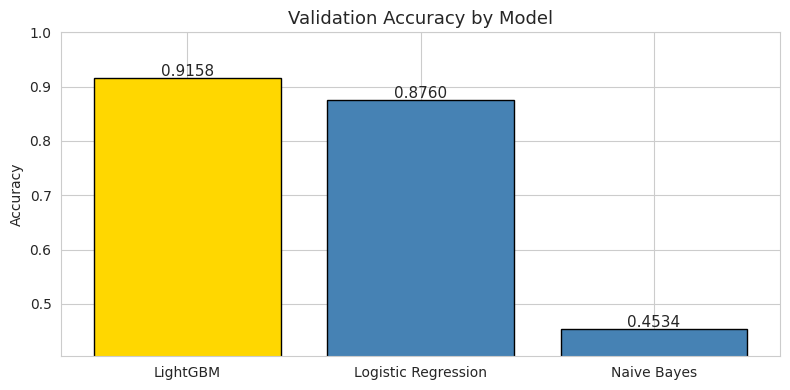

In [23]:
results = pd.DataFrame({
    'Model'   : ['Naive Bayes', 'Logistic Regression', 'LightGBM'],
    'Val Accuracy': [nb_acc, lr_acc, lgb_acc]
}).sort_values('Val Accuracy', ascending=False).reset_index(drop=True)

print('=== Model Comparison ===')
print(results.to_string(index=False))

plt.figure(figsize=(8, 4))
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(results))]
bars = plt.bar(results['Model'], results['Val Accuracy'], color=colors, edgecolor='black')
plt.ylim(min(results['Val Accuracy']) - 0.05, 1.0)
plt.title('Validation Accuracy by Model', fontsize=13)
plt.ylabel('Accuracy')
for bar, acc in zip(bars, results['Val Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{acc:.4f}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

In [24]:
# detailed classification report for LightGBM (best model)
print('Classification Report — LightGBM:')
print(classification_report(y_val, lgb_pred, target_names=[f'Class {c}' for c in le.classes_]))

Classification Report — LightGBM:
              precision    recall  f1-score   support

     Class 0       0.98      0.95      0.96     22835
     Class 1       0.79      0.79      0.79      3183
     Class 2       0.85      0.93      0.89     12488
     Class 3       0.77      0.49      0.60      1094

    accuracy                           0.92     39600
   macro avg       0.85      0.79      0.81     39600
weighted avg       0.92      0.92      0.91     39600



## 6. Ensemble: NB + LightGBM

LightGBM is clearly the strongest model. Naive Bayes is weak on its own but its probability outputs are calibrated differently, so blending a small amount of NB with LightGBM sometimes squeezes out extra accuracy.

I'll scan weights from 0.1 to 0.9 (NB weight) and find the best combination on the validation set.

Best blend — NB weight: 0.05  LGB weight: 0.95
Ensemble Val Accuracy:  0.9158
LightGBM alone:         0.9158
Gain from ensemble:     +0.0000


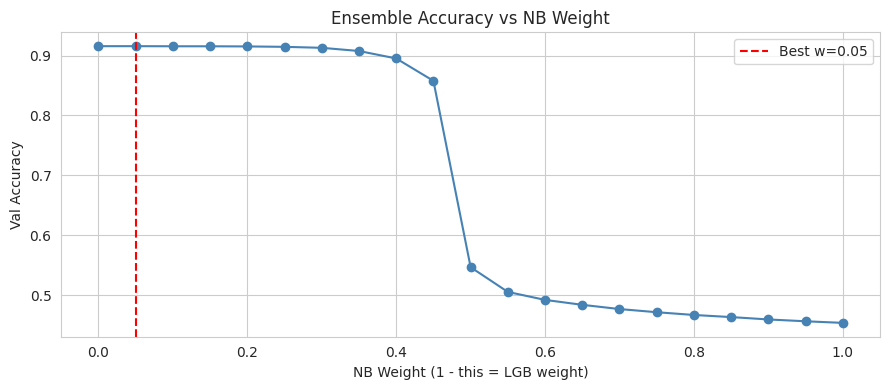

In [25]:
nb_prob  = nb.predict_proba(X_val)
lgb_prob = lgb_model.predict_proba(X_val)

best_w, best_acc = 0.0, 0.0
weight_results   = []

for w in np.arange(0.0, 1.01, 0.05):
    blended = w * nb_prob + (1 - w) * lgb_prob
    acc     = accuracy_score(y_val, np.argmax(blended, axis=1))
    weight_results.append((round(w, 2), acc))
    if acc > best_acc:
        best_acc = acc
        best_w   = w

print(f'Best blend — NB weight: {best_w:.2f}  LGB weight: {1-best_w:.2f}')
print(f'Ensemble Val Accuracy:  {best_acc:.4f}')
print(f'LightGBM alone:         {lgb_acc:.4f}')
print(f'Gain from ensemble:     {best_acc - lgb_acc:+.4f}')

# plot how accuracy changes with blend weight
wr_df = pd.DataFrame(weight_results, columns=['NB_weight', 'Accuracy'])
plt.figure(figsize=(9, 4))
plt.plot(wr_df['NB_weight'], wr_df['Accuracy'], marker='o', color='steelblue')
plt.axvline(best_w, color='red', linestyle='--', label=f'Best w={best_w:.2f}')
plt.title('Ensemble Accuracy vs NB Weight', fontsize=12)
plt.xlabel('NB Weight (1 - this = LGB weight)')
plt.ylabel('Val Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Retrain on Full Data & Generate Submission

In [26]:
# retrain on the full dataset (train + val) to use every sample we have
print('Retraining on full data...')

nb.fit(X, y)

# use the best_iteration_ found by early stopping — no need for a new eval set
best_n = lgb_model.best_iteration_ if lgb_model.best_iteration_ else 300
lgb_full = lgb.LGBMClassifier(
    n_estimators=best_n,
    learning_rate=0.05,
    num_leaves=64,
    max_depth=8,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
    is_unbalance=True
)
lgb_full.fit(X, y)
print('Done.')

Retraining on full data...
Done.


In [27]:
# generate test predictions using the best ensemble weight
print('Predicting on test data...')
nb_test  = nb.predict_proba(X_test)
lgb_test = lgb_full.predict_proba(X_test)

final_probs = best_w * nb_test + (1 - best_w) * lgb_test
pred_encoded = np.argmax(final_probs, axis=1)
pred_labels  = le.inverse_transform(pred_encoded)

print('Prediction distribution:')
print(pd.Series(pred_labels).value_counts().sort_index())

Predicting on test data...
Prediction distribution:
0    56903
1     8075
2    35150
3     1872
Name: count, dtype: int64


In [28]:
# save submission file
sample['label'] = pred_labels
sample.to_csv('submission.csv', index=False)

print('submission.csv saved!')
print(f'\nFinal Summary:')
print(f'  NB val accuracy:  {nb_acc:.4f}')
print(f'  LR val accuracy:  {lr_acc:.4f}')
print(f'  LGB val accuracy: {lgb_acc:.4f}')
print(f'  Ensemble:         {best_acc:.4f}  (NB={best_w:.2f}, LGB={1-best_w:.2f})')
sample.head()

submission.csv saved!

Final Summary:
  NB val accuracy:  0.4534
  LR val accuracy:  0.8760
  LGB val accuracy: 0.9158
  Ensemble:         0.9158  (NB=0.05, LGB=0.95)


,ID,label
0,1,2
1,2,2
2,3,0
3,4,0
4,5,2
